# Pathologist Disagreement Analysis

This notebook generates tile-level label dataframes for Anna and Grayson for all **24 overlapping slides**, merges them on tile coordinates, and analyzes agreement/disagreement.

## Overlapping Slides (24)
- **14 Exp1 AF slides**: AF102F, AF104, AF107, AF109, AF110F, AF113M, AF130F, AF135M, AF136M, AF238F, AF239F, AF252, AF254F, AF257M
- **9 Exp2 AG/AH slides**: AG985F, AG986F, AG987F, AG991M, AH063F, AH073M, AH074M, AH139F, AH141F
- **1 additional**: AH072M

## Workflow
1. Extract Grayson tiles for the 9 Exp2 slides (15 AF+AH072M already done)
2. Build Dataset objects filtered to 24 slides
3. Generate tile dataframes via `get_tile_dataframe()`
4. Merge dataframes on slide + x/y coordinates
5. Analyze agreement/disagreement
6. Visualize on UMAP

In [3]:
import slideflow as sf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print(f'Slideflow version: {sf.__version__}')

Slideflow version: 3.0.2


In [4]:
# --- Paths & config ---

#ask about the setup here the features directory is where foundation model features are stored right?? 
# Ask about the structure of the docs too! 
PROJECT_DIR = '/home/stanna/labshare/PERSONAL/stanna/PROJECTS/Exp2_Demo'
FEATURES_DIR = '/home/stanna/labshare/PERSONAL/stanna/DATA/Exp2/features/virchow'

TILE_PX = 299
TILE_UM = 302

# All 24 overlapping slides (both Anna and Grayson annotated)
OVERLAP_SLIDES = [
    # Exp1 AF slides (14)
    'AF102F', 'AF104', 'AF107', 'AF109', 'AF110F', 'AF113M',
    'AF130F', 'AF135M', 'AF136M', 'AF238F', 'AF239F', 'AF252', 'AF254F', 'AF257M',
    # Exp2 AG/AH slides (9)
    'AG985F', 'AG986F', 'AG987F', 'AG991M',
    'AH063F', 'AH073M', 'AH074M', 'AH139F', 'AH141F',
    # Additional (1)
    'AH072M'
]


## Step 2 — Build Dataset Objects

We create two separate Dataset objects filtered to all **24 overlapping slides**:
- **Anna**: `Exp2_Dataset` source — her ROIs and tiles
- **Grayson**: `Grayson_Dataset` source — his ROIs and tiles

Note: Grayson already has tiles for the 14 AF slides + AH072M. The 9 Exp2 AG/AH slides need extraction (see Step 1b below).

In [5]:
project = sf.Project(PROJECT_DIR)
print(project)

Project(root='/home/stanna/labshare/PERSONAL/stanna/PROJECTS/Exp2_Demo')


In [6]:
# Anna's dataset — filtered to 24 overlap slides
anna_ds = project.dataset(sources='Exp2_Dataset', tile_px=TILE_PX, tile_um=TILE_UM)
anna_ds = anna_ds.filter({'slide': OVERLAP_SLIDES})
print(f'Anna dataset slides: {len(anna_ds.slides())}')

# Grayson's dataset — filtered to 24 overlap slides
grayson_ds = project.dataset(sources='Grayson_Dataset', tile_px=TILE_PX, tile_um=TILE_UM)
grayson_ds = grayson_ds.filter({'slide': OVERLAP_SLIDES})
print(f'Grayson dataset slides: {len(grayson_ds.slides())}')

/home/stanna/miniconda3/envs/SF/lib/python3.9/site-packages/rich/live.py:231: UserWarning: install "ipywidgets" for
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Anna dataset slides: 24


/home/stanna/miniconda3/envs/SF/lib/python3.9/site-packages/rich/live.py:231: UserWarning: install "ipywidgets" for
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Grayson dataset slides: 24


## Step 3 — Generate Tile Dataframes

`get_tile_dataframe()` returns one row per tile with:
- `slide` — slide name
- `x`, `y` — tile center coordinates (base dimension)
- `grid` — slide grid index
- `roi_name` — the ROI label the tile falls within (tiles outside all ROIs are excluded)

In [7]:
print('Generating Anna tile dataframe...')
anna_tile_df = anna_ds.get_tile_dataframe()
anna_tile_df = anna_tile_df.loc[anna_tile_df.label.notnull()]
print(f'Anna tiles (in ROI): {len(anna_tile_df):,}')
print(anna_tile_df.head())

Generating Anna tile dataframe...


/home/stanna/miniconda3/envs/SF/lib/python3.9/site-packages/rich/live.py:231: UserWarning: install "ipywidgets" for
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/home/stanna/miniconda3/envs/SF/lib/python3.9/site-packages/rich/live.py:231: UserWarning: install "ipywidgets" for
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Anna tiles (in ROI): 1,941
                   loc_x  loc_y  grid_x  grid_y roi_name roi_desc   label  \
AF113M-24436-5364  24436   5364      20       4    ROI_4    ROI_4  Benign   
AF113M-25628-5364  25628   5364      21       4    ROI_4    ROI_4  Benign   
AF113M-26820-5364  26820   5364      22       4    ROI_4    ROI_4  Benign   
AF113M-28012-5364  28012   5364      23       4    ROI_4    ROI_4  Benign   
AF113M-29204-5364  29204   5364      24       4    ROI_4    ROI_4  Benign   

                    slide  
AF113M-24436-5364  AF113M  
AF113M-25628-5364  AF113M  
AF113M-26820-5364  AF113M  
AF113M-28012-5364  AF113M  
AF113M-29204-5364  AF113M  


In [8]:
anna_tile_df

,loc_x,loc_y,grid_x,grid_y,roi_name,roi_desc,label,slide
AF113M-24436-5364,24436,5364,20,4,ROI_4,ROI_4,Benign,AF113M
AF113M-25628-5364,25628,5364,21,4,ROI_4,ROI_4,Benign,AF113M
AF113M-26820-5364,26820,5364,22,4,ROI_4,ROI_4,Benign,AF113M
AF113M-28012-5364,28012,5364,23,4,ROI_4,ROI_4,Benign,AF113M
AF113M-29204-5364,29204,5364,24,4,ROI_4,ROI_4,Benign,AF113M
...,...,...,...,...,...,...,...,...
AF239F-33972-45892,33972,45892,28,38,ROI_3,ROI_3,Benign,AF239F
AF239F-20860-47084,20860,47084,17,39,ROI_3,ROI_3,Benign,AF239F
AF239F-22052-47084,22052,47084,18,39,ROI_3,ROI_3,Benign,AF239F
AF239F-26820-47084,26820,47084,22,39,ROI_3,ROI_3,Benign,AF239F


In [9]:
print('Generating Grayson tile dataframe...')
grayson_tile_df = grayson_ds.get_tile_dataframe()
grayson_tile_df = grayson_tile_df.loc[grayson_tile_df.label.notnull()]
print(f'Grayson tiles (in ROI): {len(grayson_tile_df):,}')
print(grayson_tile_df.head())

Generating Grayson tile dataframe...


/home/stanna/miniconda3/envs/SF/lib/python3.9/site-packages/rich/live.py:231: UserWarning: install "ipywidgets" for
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/home/stanna/miniconda3/envs/SF/lib/python3.9/site-packages/rich/live.py:231: UserWarning: install "ipywidgets" for
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/home/stanna/miniconda3/envs/SF/lib/python3.9/site-packages/rich/live.py:231: UserWarning: install "ipywidgets" for
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/home/stanna/miniconda3/envs/SF/lib/python3.9/site-packages/rich/live.py:231: UserWarning: install "ipywidgets" for
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

...

/home/stanna/miniconda3/envs/SF/lib/python3.9/site-packages/rich/live.py:231: UserWarning: install "ipywidgets" for
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/home/stanna/miniconda3/envs/SF/lib/python3.9/site-packages/rich/live.py:231: UserWarning: install "ipywidgets" for
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/home/stanna/miniconda3/envs/SF/lib/python3.9/site-packages/rich/live.py:231: UserWarning: install "ipywidgets" for
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/home/stanna/miniconda3/envs/SF/lib/python3.9/site-packages/rich/live.py:231: UserWarning: install "ipywidgets" for
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Grayson tiles (in ROI): 2,046
                   loc_x  loc_y  grid_x  grid_y roi_name roi_desc   label  \
AF102F-14900-7748  14900   7748      12       6    ROI_2    ROI_2  Benign   
AF102F-16092-7748  16092   7748      13       6    ROI_2    ROI_2  Benign   
AF102F-17284-7748  17284   7748      14       6    ROI_2    ROI_2  Benign   
AF102F-22052-7748  22052   7748      18       6    ROI_2    ROI_2  Benign   
AF102F-23244-7748  23244   7748      19       6    ROI_2    ROI_2  Benign   

                    slide  
AF102F-14900-7748  AF102F  
AF102F-16092-7748  AF102F  
AF102F-17284-7748  AF102F  
AF102F-22052-7748  AF102F  
AF102F-23244-7748  AF102F  


In [10]:
grayson_tile_df

,loc_x,loc_y,grid_x,grid_y,roi_name,roi_desc,label,slide
AF102F-14900-7748,14900,7748,12,6,ROI_2,ROI_2,Benign,AF102F
AF102F-16092-7748,16092,7748,13,6,ROI_2,ROI_2,Benign,AF102F
AF102F-17284-7748,17284,7748,14,6,ROI_2,ROI_2,Benign,AF102F
AF102F-22052-7748,22052,7748,18,6,ROI_2,ROI_2,Benign,AF102F
AF102F-23244-7748,23244,7748,19,6,ROI_2,ROI_2,Benign,AF102F
...,...,...,...,...,...,...,...,...
AH072M-25785-47559,25785,47559,22,41,ROI_37,ROI_37,Benign,AH072M
AH072M-18909-48705,18909,48705,16,42,ROI_37,ROI_37,Benign,AH072M
AH072M-23493-48705,23493,48705,20,42,ROI_37,ROI_37,Benign,AH072M
AH072M-18909-49851,18909,49851,16,43,ROI_37,ROI_37,Benign,AH072M


In [11]:
# Inspect ROI label distributions
print('Anna ROI labels:')
print(anna_tile_df['label'].value_counts())
print()
print('Grayson ROI labels:')
print(grayson_tile_df['label'].value_counts())

Anna ROI labels:
label
Benign                956
Dysplasia             766
Invasive carcinoma    219
Name: count, dtype: int64

Grayson ROI labels:
label
Benign            1631
Carcinoma          158
Mild               134
Severe              62
Moderate            55
Hyperkeratosis       4
Unknown              2
Name: count, dtype: int64


## Step 4 — Merge Tile Dataframes

Merge Anna and Grayson on `slide + x + y` (inner join = tiles both annotated).
This gives us `roi_name_anna` and `roi_name_grayson` for the same tile.

In [14]:
# Rename label columns before merging
anna_tile_df = anna_tile_df.rename(columns={'label': 'label_anna'})
grayson_tile_df = grayson_tile_df.rename(columns={'label': 'label_grayson'})

# Inner join on slide + tile coordinates
# loc_x and loc_y are the tile center coordinates in base pixel dimensions
merged_df = pd.merge(
    anna_tile_df[['slide', 'loc_x', 'loc_y', 'label_anna']],
    grayson_tile_df[['slide', 'loc_x', 'loc_y', 'label_grayson']],
    on=['slide', 'loc_x', 'loc_y'],
    how='inner'
)

print(f'Merged tiles (both annotated same tile): {len(merged_df):,}')
print(f'Anna-only tiles: {len(anna_tile_df) - len(merged_df):,}')
print(f'Grayson-only tiles: {len(grayson_tile_df) - len(merged_df):,}')
merged_df.head()

Merged tiles (both annotated same tile): 1,901
Anna-only tiles: 40
Grayson-only tiles: 145


,slide,loc_x,loc_y,label_anna,label_grayson
0,AF113M,24436,5364,Benign,Benign
1,AF113M,25628,5364,Benign,Benign
2,AF113M,26820,5364,Benign,Benign
3,AF113M,28012,5364,Benign,Benign
4,AF113M,29204,5364,Benign,Benign


In [15]:
# Flag agreement vs disagreement
merged_df['agree'] = merged_df['label_anna'] == merged_df['label_grayson']

n_agree = merged_df['agree'].sum()
n_total = len(merged_df)
print(f'Agreement: {n_agree:,} / {n_total:,} tiles ({100*n_agree/n_total:.1f}%)')
print(f'Disagreement: {n_total - n_agree:,} tiles ({100*(n_total - n_agree)/n_total:.1f}%)')

Agreement: 923 / 1,901 tiles (48.6%)
Disagreement: 978 tiles (51.4%)


In [16]:
merged_df

,slide,loc_x,loc_y,label_anna,label_grayson,agree
0,AF113M,24436,5364,Benign,Benign,True
1,AF113M,25628,5364,Benign,Benign,True
2,AF113M,26820,5364,Benign,Benign,True
3,AF113M,28012,5364,Benign,Benign,True
4,AF113M,29204,5364,Benign,Benign,True
...,...,...,...,...,...,...
1896,AF239F,33972,45892,Benign,Benign,True
1897,AF239F,20860,47084,Benign,Benign,True
1898,AF239F,22052,47084,Benign,Benign,True
1899,AF239F,26820,47084,Benign,Benign,True


In [ ]:
merged_df.label_anna.

array(['Benign', 'Dysplasia', 'Invasive carcinoma'], dtype=object)

In [ ]:
# Disagreement breakdown: what did Anna call it vs what did Grayson call it?
disagree_df = merged_df[~merged_df['agree']]
breakdown = disagree_df.groupby(['label_anna', 'label_grayson']).size().reset_index(name='n_tiles')
breakdown = breakdown.sort_values('n_tiles', ascending=False)
print('Disagreement pairs (Anna label → Grayson label):')
print(breakdown.to_string(index=False))

## Step 5 — Visualizations

### 5a — Confusion matrix heatmap (Anna vs Grayson labels)

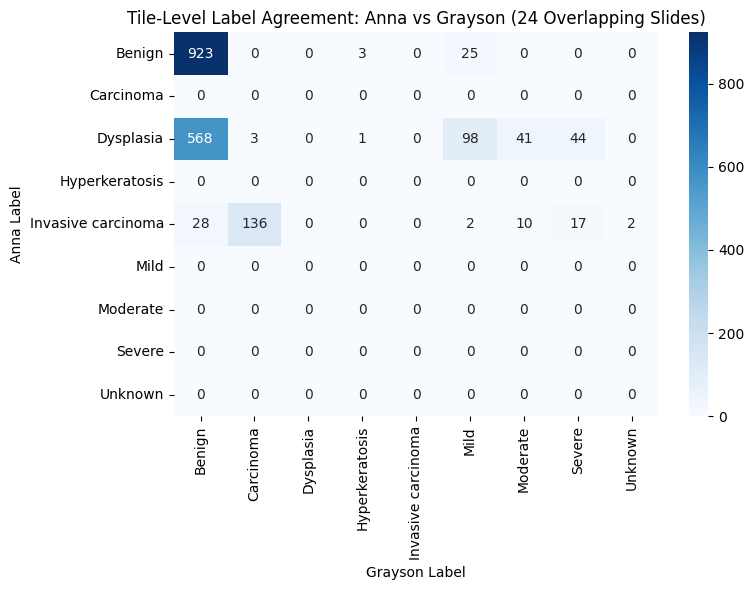

Cohen's Kappa: 0.143


In [19]:
from sklearn.metrics import confusion_matrix, cohen_kappa_score

# Use union of both annotators' labels so no label is missing from axes
labels_order = sorted(set(merged_df['label_anna'].unique()) | set(merged_df['label_grayson'].unique()))

cm = confusion_matrix(merged_df['label_anna'], merged_df['label_grayson'], labels=labels_order)
cm_df = pd.DataFrame(cm, index=labels_order, columns=labels_order)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_xlabel('Grayson Label')
ax.set_ylabel('Anna Label')
ax.set_title('Tile-Level Label Agreement: Anna vs Grayson (24 Overlapping Slides)')
plt.tight_layout()
plt.savefig('/home/stanna/labshare/PERSONAL/stanna/DATA/Exp2/features/disagreement_confusion_matrix.png', dpi=150)
plt.show()

kappa = cohen_kappa_score(merged_df['label_anna'], merged_df['label_grayson'])
print(f"Cohen's Kappa: {kappa:.3f}")

### 5b — Disagreement on UMAP

Project the merged tiles onto the existing Exp2 clustering UMAP and color by agreement/disagreement.
This requires matching tile coordinates to the `.pt` feature files from the Virchow extraction.

I think we have to redo this step. The previous umap I don't think used the 24 overlapping slides! So start by extracting tiles form the 24 slides Grayson and Anna (maybe do this in the other notebook. Then extract features for those tiles (the trf records)). Then 

In [20]:
import torch
import joblib

UMAP_MODEL_PATH = '/home/stanna/labshare/PERSONAL/stanna/DATA/Exp2/features/umap_reducer_balanced.joblib'

reducer = joblib.load(UMAP_MODEL_PATH)
print('UMAP reducer loaded')

# Load features for the 9 overlap slides (Anna's .pt files)
all_features = []
all_slides = []
all_locs = []  # (x, y) per tile

for slide in OVERLAP_SLIDES:
    pt_path = f'{FEATURES_DIR}/{slide}.pt'
    idx_path = f'{FEATURES_DIR}/{slide}.index.npz'
    if not os.path.exists(pt_path):
        print(f'WARNING: {slide}.pt not found, skipping')
        continue
    feats = torch.load(pt_path, map_location='cpu').numpy()
    idx = np.load(idx_path)
    locs = list(zip(idx['x'].tolist(), idx['y'].tolist()))
    all_features.append(feats)
    all_slides.extend([slide] * len(feats))
    all_locs.extend(locs)
    print(f'  {slide}: {len(feats)} tiles')

all_features = np.vstack(all_features)
print(f'Total tiles loaded: {len(all_features):,}')

/home/stanna/miniconda3/envs/SF/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


UMAP reducer loaded


NameError: name 'os' is not defined

In [ ]:
# Project overlap features onto the UMAP
overlap_embedding = reducer.transform(all_features)
print(f'Projected {len(overlap_embedding):,} tiles onto UMAP')

# Build a lookup dataframe from features
feat_df = pd.DataFrame({
    'slide': all_slides,
    'x': [loc[0] for loc in all_locs],
    'y': [loc[1] for loc in all_locs],
    'umap_1': overlap_embedding[:, 0],
    'umap_2': overlap_embedding[:, 1]
})

# Merge UMAP coords into the merged label dataframe
umap_merged = pd.merge(merged_df, feat_df, on=['slide', 'loc_x', 'loc_y'], how='inner')
print(f'Tiles with UMAP coords + both labels: {len(umap_merged):,}')

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Left: colored by agreement
ax = axes[0]
colors = umap_merged['agree'].map({True: '#2ecc71', False: '#e74c3c'})
ax.scatter(
    umap_merged['umap_1'], umap_merged['umap_2'],
    c=colors, alpha=0.6, s=15, edgecolors='none'
)
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#2ecc71', label=f'Agree (n={umap_merged["agree"].sum():,})'),
    Patch(color='#e74c3c', label=f'Disagree (n={(~umap_merged["agree"]).sum():,})')
], fontsize=10)
ax.set_title('Agreement / Disagreement on UMAP')
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')

# Right: colored by Anna's label
severity_colors = {
    'Benign':   '#2ecc71',
    'Mild':     '#f1c40f',
    'Moderate': '#e67e22',
    'Severe':   '#c0392b',
    'Carcinoma':'#7b241c',
    'Dysplasia':'#f39c12'
}
ax = axes[1]
for label, grp in umap_merged.groupby('label_anna'):
    ax.scatter(
        grp['umap_1'], grp['umap_2'],
        c=severity_colors.get(label, 'gray'),
        label=label, alpha=0.6, s=15, edgecolors='none'
    )
ax.set_title("Anna's Labels on UMAP (Overlap Slides Only)")
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.legend(fontsize=9)

plt.suptitle('Tile-Level Pathologist Agreement — 9 Overlapping Exp2 Slides', fontsize=14)
plt.tight_layout()
plt.savefig('/home/stanna/labshare/PERSONAL/stanna/DATA/Exp2/features/disagreement_umap.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Save merged tile dataframe for future use
out_path = '/home/stanna/labshare/PERSONAL/stanna/DATA/Exp2/features/merged_tile_labels.csv'
merged_df.to_csv(out_path, index=False)
print(f'Saved merged tile labels to: {out_path}')
print(f'Shape: {merged_df.shape}')
merged_df.head()